C:\Users\play7\AppData\Local\Temp\ipykernel_6708\2642620915.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, ax=axes[0], palette='pastel')


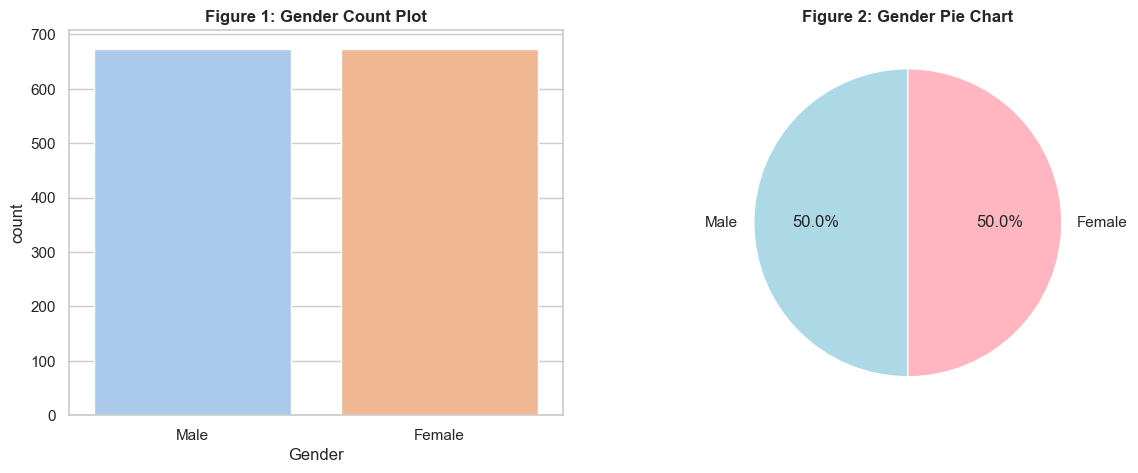

C:\Users\play7\AppData\Local\Temp\ipykernel_6708\2642620915.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Stages', data=df, palette='viridis')


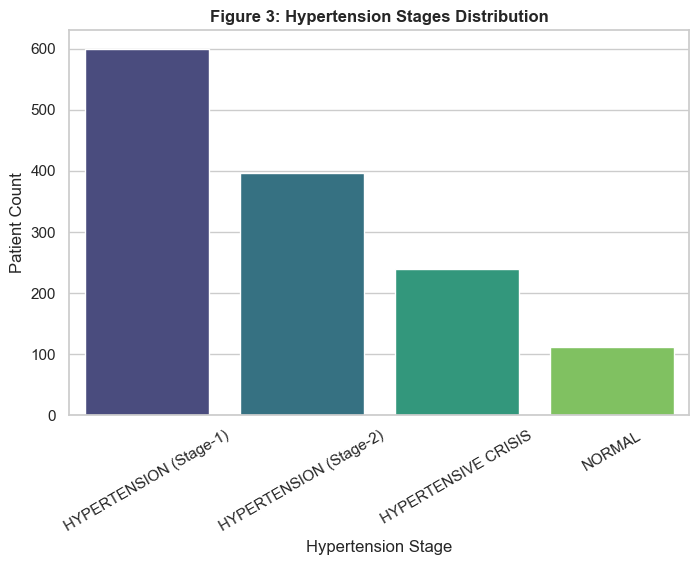

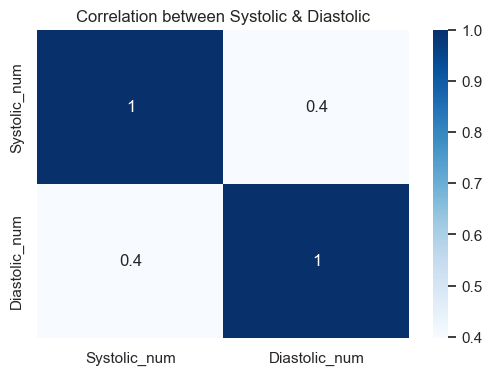

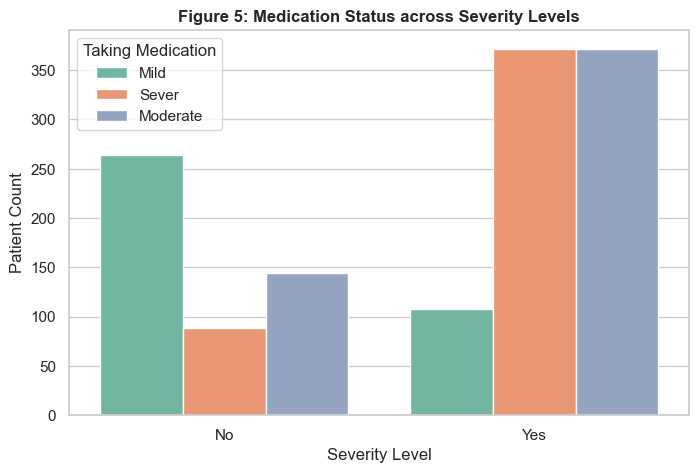

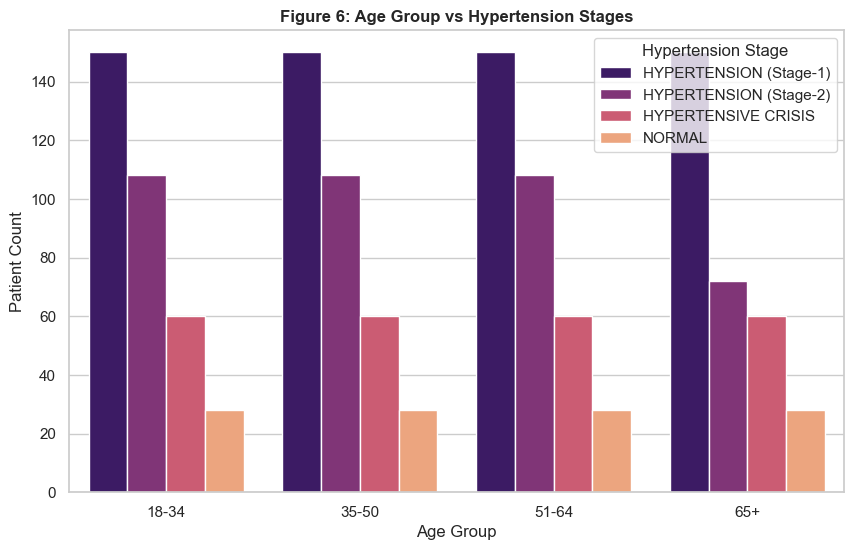

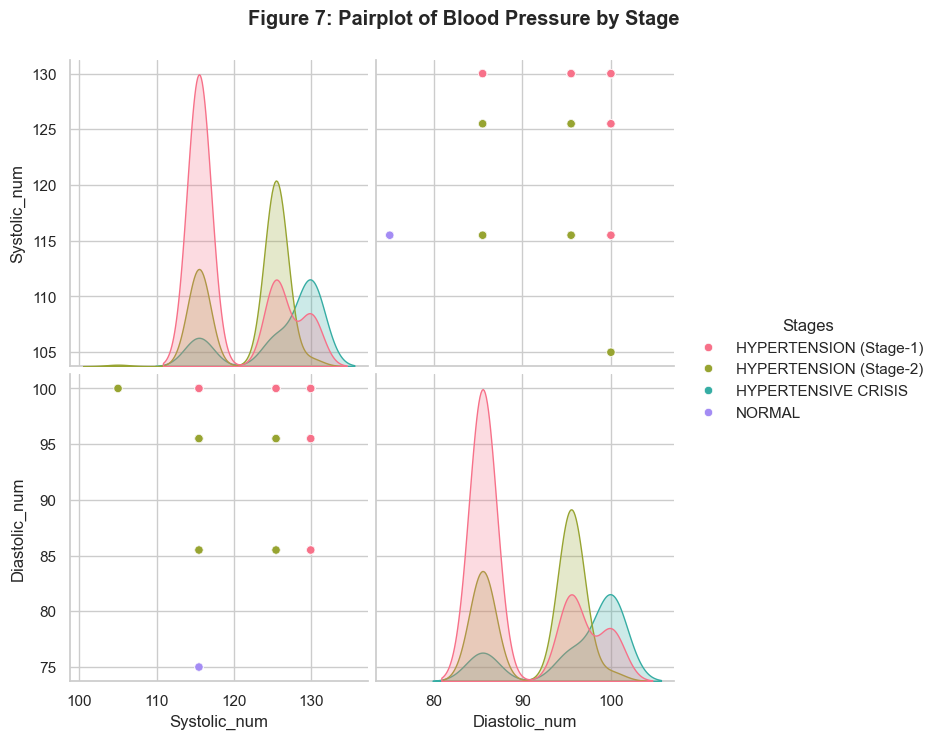

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the pre-cleaned data directly! (This is what your teammate meant)
df = pd.read_csv('../Milestone 1 - Data_Collection_&_Preparation/preprocessedData.csv')

sns.set_theme(style="whitegrid")

# --- Figures 1 & 2: Gender Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Gender', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Figure 1: Gender Count Plot', fontweight='bold')

df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['lightblue', 'lightpink'], startangle=90)
axes[1].set_ylabel('') # Clean up the y-axis label
axes[1].set_title('Figure 2: Gender Pie Chart', fontweight='bold')
plt.show()

# --- Figure 3: Hypertension Stages Distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(x='Stages', data=df, palette='viridis')
plt.title('Figure 3: Hypertension Stages Distribution', fontweight='bold')
plt.xlabel('Hypertension Stage')
plt.ylabel('Patient Count')
plt.xticks(rotation=30)
plt.show()

# --- Figure 4: Correlation between Systolic and Diastolic ---
# Heatmap on encoded numeric BP only (after midpoint conversion)
import numpy as np

def range_to_midpoint(val):
    if "-" in val:
        start, end = val.split("-")
        return (int(start.strip()) + int(end.strip()))/2
    elif "+" in val:
        return int(val.replace("+","").strip())
    else:
        return np.nan

df['Systolic_num'] = df['Systolic'].apply(range_to_midpoint)
df['Diastolic_num'] = df['Diastolic'].apply(range_to_midpoint)

plt.figure(figsize=(6,4))
sns.heatmap(df[['Systolic_num','Diastolic_num']].corr(), annot=True, cmap="Blues")
plt.title("Correlation between Systolic & Diastolic")
plt.show()

# --- Figure 5: TakeMedication vs Severity ---
plt.figure(figsize=(8, 5))
sns.countplot(x='TakeMedication', hue='Severity', data=df, palette='Set2')
plt.title('Figure 5: Medication Status across Severity Levels', fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Patient Count')
plt.legend(title='Taking Medication')
plt.show()

# --- Figure 6: Age Group vs Hypertension Stages ---
plt.figure(figsize=(10, 6))
sns.countplot(x='Age', hue='Stages', data=df, palette='magma')
plt.title('Figure 6: Age Group vs Hypertension Stages', fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Patient Count')
plt.legend(title='Hypertension Stage')
plt.show()

# --- Figure 7: Pairplot for Systolic vs Diastolic across Stages ---
# This creates the multi-variable scatter and density plots
pair_fig = sns.pairplot(df[['Systolic_num', 'Diastolic_num', 'Stages']], hue='Stages',diag_kind='kde', palette='husl', height=3.5)
pair_fig.fig.suptitle('Figure 7: Pairplot of Blood Pressure by Stage', y=1.05, fontweight='bold')
plt.show()